## 1 · Imports & Config

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import timm
import torchaudio
import numpy as np
import pandas as pd
import json
import os
import sys
import cv2
import librosa
import pickle
import math
import warnings
import argparse
from pathlib import Path
from tqdm import tqdm
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple, Any
from collections import defaultdict
from copy import deepcopy

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score, precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, cohen_kappa_score, accuracy_score, top_k_accuracy_score,
    classification_report, balanced_accuracy_score
)
from sklearn.preprocessing import LabelBinarizer
from sklearn.calibration import calibration_curve
from scipy.special import softmax as scipy_softmax
from scipy.stats import gaussian_kde

In [2]:
@dataclass
class Config:
    # Add these back so the train() function can pass them
    data_dir: str = "/kaggle/input" 
    output_dir: str = "/kaggle/working/output"
    model_name: str = "moe_kaggle_medical"
    cache_dir: str = "/kaggle/working/cache"

    # Kaggle Specific paths for your 6 datasets
    domain_data_paths: Dict[str, str] = field(default_factory=lambda: {
        "lungs": "/kaggle/input/datasets/omkarmanohardalvi/lungs-disease-dataset-4-types/Lung Disease Dataset",
        "brain": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
        "eye": "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification",
        "skin": "/kaggle/input/datasets/riyaelizashaju/skin-disease-classification-image-dataset/Split_smol",
        "ecg": "/kaggle/input/datasets/evilspirit05/ecg-analysis",
        "corona": "/kaggle/input/datasets/pranaynandan63/covid-19-cough-sounds"
    })

    # VRAM OPTIMIZATION (Essential for Kaggle T4)
    image_size: int = 384  
    batch_size: int = 16   
    num_workers: int = 2   
    
    lora_r: int = 8
    lora_alpha: int = 16
    lora_dropout: float = 0.1
    lora_targets: List[str] = field(default_factory=lambda: ["q_proj", "v_proj"])

    domain_backbones: Dict[str, str] = field(default_factory=lambda: {
        "lungs": "densenet121",
        "brain": "efficientnet_b4",
        "eye": "efficientnet_b3",
        "skin": "efficientnet_b4",
        "ecg": "efficientnet_b0",
    })
    domain_clahe: List[str] = field(default_factory=lambda: ["lungs", "eye"])

    audio_sr: int = 16000
    audio_duration: float = 3.0
    n_mels: int = 128
    n_fft: int = 2048
    hop_length: int = 512

    domains: Dict[str, int] = field(default_factory=lambda: {
        "lungs": 5, "brain": 4, "eye": 4, "skin": 9, "ecg": 4, "corona": 3,
    })
    domain_order: List[str] = field(default_factory=lambda: ["lungs","brain","eye","skin","ecg","corona","unknown"])
    domain_classes: int = 7

    router_hidden: List[int] = field(default_factory=lambda: [2048, 512, 256])

    epochs_phase1: int = 3 
    epochs_phase2: int = 2
    epochs_phase3: int = 2
    
    lr_backbone: float = 1e-5
    lr_lora: float = 5e-4
    lr_router: float = 1e-4
    weight_decay: float = 0.01
    grad_clip: float = 1.0
    label_smoothing: float = 0.1
    use_amp: bool = True  
    gradient_checkpointing: bool = False
    seed: int = 42
    device: str = "cuda"

    def save(self, path: str):
        with open(path, "w") as f:
            # Helper to handle Path objects during JSON save
            d = asdict(self)
            json.dump(d, f, indent=2)

    @classmethod
    def load(cls, path: str) -> "Config":
        with open(path) as f:
            return cls(**json.load(f))

## 2 · Utilities

In [3]:
def seed_everything(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

In [4]:
def apply_clahe(img: np.ndarray, clip_limit: float = 2.0, tile_size: int = 8) -> np.ndarray:
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
    if len(img.shape) == 3:
        if img.shape[2] == 3:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        else:
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
            img = clahe.apply(img)
    else:
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
        img = clahe.apply(img)
    return img

In [5]:
def preprocess_ecg_remove_grid(img: np.ndarray, threshold: int = 200) -> np.ndarray:
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img.copy()

    _, binary = cv2.threshold(gray, threshold, 255, cv2.THRESH_TOZERO)
    grid_mask = cv2.adaptiveThreshold(
        binary, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 5
    )
    grid_mask = cv2.medianBlur(grid_mask, 3)
    cleaned = cv2.bitwise_and(binary, binary, mask=255 - grid_mask)
    _, cleaned = cv2.threshold(cleaned, 30, 255, cv2.THRESH_TOZERO)

    if len(img.shape) == 3:
        return cv2.cvtColor(cleaned, cv2.COLOR_GRAY2RGB)
    return cleaned

In [6]:
def preprocess_brain_crop(img: np.ndarray, crop_ratio: float = 0.7) -> np.ndarray:
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)

        # Threshold to find the skull
        _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
        thresh = cv2.erode(thresh, None, iterations=2)
        thresh = cv2.dilate(thresh, None, iterations=2)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            c = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(c)
            # Ensure the crop isn't too small/weird
            if w > 50 and h > 50:
                return img[y:y+h, x:x+w]
    except Exception:
        pass
        
    return img # Return original if cropping fails

In [7]:
def trim_audio(waveform: np.ndarray, top_db: float = 20.0) -> np.ndarray:
    trimmed, _ = librosa.effects.trim(waveform, top_db=top_db)
    return trimmed

## 3 · Loss & Calibration Helpers

In [8]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0,
                 reduction: str = "mean", label_smoothing: float = 0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.size(-1)
        if self.label_smoothing > 0:
            targets_onehot = torch.zeros_like(logits).scatter_(1, targets.unsqueeze(1), 1.0)
            targets_onehot = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / num_classes
            ce_loss = -(targets_onehot * F.log_softmax(logits, dim=-1)).sum(dim=-1)
        else:
            ce_loss = F.cross_entropy(logits, targets, reduction="none")

        probs = F.softmax(logits, dim=-1)
        p_t = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_weight = (1 - p_t) ** self.gamma

        if self.alpha is not None:
            if self.alpha.device != logits.device:
                self.alpha = self.alpha.to(logits.device)
            alpha_t = self.alpha.gather(0, targets)
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

In [9]:
class TemperatureScaling(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits: torch.Tensor) -> torch.Tensor:
        return logits / self.temperature

    def calibrate(self, model: nn.Module, val_loader: DataLoader, device: torch.device, lr: float = 0.01, max_iter: int = 50):
        model.eval()
        nll_criterion = nn.CrossEntropyLoss()

        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)

        # Collect all logits & labels first, then compute loss as a tensor for LBFGS
        all_logits_list = []
        all_labels_list = []
        for batch in val_loader:
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            with torch.no_grad():
                output = model(batch)
                all_logits_list.append(output["specialist"]["disease_logits"].detach())
                all_labels_list.append(batch["disease_idx"].to(device))
        all_logits_cat = torch.cat(all_logits_list, dim=0)
        all_labels_cat = torch.cat(all_labels_list, dim=0)

        def eval():
            optimizer.zero_grad()
            scaled = all_logits_cat / self.temperature
            loss = nll_criterion(scaled, all_labels_cat)
            loss.backward()
            return loss

        optimizer.step(eval)
        print(f"  Temperature = {self.temperature.item():.4f}")
        return self.temperature.item()

## 4 · LoRA

In [10]:
class LoRALinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, r: int = 8,
                 alpha: float = 16.0, dropout: float = 0.1, bias: bool = True):
        super().__init__()
        self.r = r
        self.alpha = alpha
        self.in_features = in_features
        self.out_features = out_features
        self.scaling = alpha / r

        self.lora_A = nn.Parameter(torch.randn(r, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))
        self.dropout = nn.Dropout(p=dropout) if dropout > 0 else nn.Identity()

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_features))
        else:
            self.bias = None
        # Initialize _original_weight so forward() doesn't crash before load_original_weight()
        self._original_weight = nn.Parameter(torch.zeros(out_features, in_features), requires_grad=False)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.zeros_(self.lora_B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_output = F.linear(x, self.weight, self.bias)
        lora_output = F.linear(self.dropout(x), self.lora_B @ self.lora_A) * self.scaling
        return base_output + lora_output

    @property
    def weight(self) -> torch.Tensor:
        return self._original_weight

    @weight.setter
    def weight(self, value: torch.Tensor):
        self._original_weight = value

    def load_original_weight(self, original_layer: nn.Linear):
        self._original_weight = original_layer.weight.data.clone()
        if self.bias is not None and original_layer.bias is not None:
            self.bias.data = original_layer.bias.data.clone()
        elif self.bias is not None:
            self.bias.data.zero_()

    def fuse_to_base(self) -> torch.Tensor:
        return self._original_weight + (self.lora_B @ self.lora_A) * self.scaling

    def get_lora_params(self) -> Dict[str, nn.Parameter]:
        return {"lora_A": self.lora_A, "lora_B": self.lora_B}


def replace_linear_with_lora(model: nn.Module, r: int = 8, alpha: float = 16.0,
                               dropout: float = 0.1, target_modules: Optional[List[str]] = None):
    if target_modules is None:
        target_modules = ["q_proj", "v_proj", "k_proj", "o_proj"]

    replaced = 0
    for name, module in model.named_children():
        if isinstance(module, nn.Linear):
            if any(tm in name for tm in target_modules):
                old_bias = module.bias is not None
                lora_layer = LoRALinear(
                    module.in_features, module.out_features,
                    r=r, alpha=alpha, dropout=dropout, bias=old_bias
                )
                lora_layer.load_original_weight(module)
                parent_name = name.rsplit(".", 1)[-1] if "." in name else name
                setattr(model, parent_name if "." not in name else name, lora_layer)
                replaced += 1
        else:
            replaced += replace_linear_with_lora(module, r, alpha, dropout, target_modules)
    return replaced

## 5 · Explainability (GradCAM / HiResCAM)

In [11]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

    def generate(self, input_tensor: torch.Tensor, target_class: Optional[int] = None) -> np.ndarray:
        self.model.eval()
        input_tensor.requires_grad_(True)

        with autocast(enabled=False):
            output = self.model(input_tensor)

        if isinstance(output, dict):
            logits = output.get("specialist_logits", output.get("logits", output))
        else:
            logits = output

        if target_class is None:
            target_class = logits.argmax(dim=1) if logits.dim() > 1 else logits.argmax()

        self.model.zero_grad()
        one_hot = torch.zeros_like(logits)
        one_hot[0][target_class] = 1.0
        logits.backward(gradient=one_hot, retain_graph=True)

        pooled_grad = self.gradients.mean(dim=(0, 2, 3), keepdim=True)  # type: ignore
        weighted_activations = self.activations * pooled_grad
        cam = weighted_activations.sum(dim=1).squeeze()

        cam = F.relu(cam)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > 0:
            cam = (cam - cam_min) / (cam_max - cam_min)
        cam = cam.cpu().numpy()

        self.model.zero_grad()
        return cam

    def generate_audio(self, input_tensor: torch.Tensor, target_class: Optional[int] = None) -> np.ndarray:
        self.model.eval()
        input_tensor.requires_grad_(True)

        with autocast(enabled=False):
            output = self.model(input_tensor)

        if isinstance(output, dict):
            logits = output.get("specialist_logits", output.get("logits", output))
        else:
            logits = output

        if target_class is None:
            target_class = logits.argmax(dim=1) if logits.dim() > 1 else logits.argmax()

        self.model.zero_grad()
        one_hot = torch.zeros_like(logits)
        one_hot[0][target_class] = 1.0
        logits.backward(gradient=one_hot, retain_graph=True)

        pooled_grad = self.gradients.mean(dim=(0, 2), keepdim=True)  # type: ignore
        weighted = self.activations * pooled_grad
        cam = weighted.sum(dim=1).squeeze()
        cam = F.relu(cam)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > 0:
            cam = (cam - cam_min) / (cam_max - cam_min)
        return cam.cpu().numpy()


In [12]:
class HiResCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

    def generate(self, input_tensor: torch.Tensor, target_class: Optional[int] = None) -> np.ndarray:
        self.model.eval()
        input_tensor.requires_grad_(True)

        with autocast(enabled=False):
            output = self.model(input_tensor)

        if isinstance(output, dict):
            logits = output.get("specialist_logits", output.get("logits", output))
        else:
            logits = output

        if target_class is None:
            target_class = logits.argmax(dim=1) if logits.dim() > 1 else logits.argmax()

        self.model.zero_grad()
        one_hot = torch.zeros_like(logits)
        one_hot[0][target_class] = 1.0
        logits.backward(gradient=one_hot, retain_graph=True)

        activations = self.activations[0]
        if self.gradients is None:
            cam = activations.mean(dim=(1, 2))
            cam = cam.cpu().numpy()
            return cam

        gradients = self.gradients[0]

        weights = gradients.mean(dim=(1, 2), keepdim=True)
        cam = (weights * activations).sum(dim=0)
        cam = F.relu(cam)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > 0:
            cam = (cam - cam_min) / (cam_max - cam_min)
        cam = cam.cpu().numpy()

        self.model.zero_grad()
        return cam

    def generate_audio(self, input_tensor: torch.Tensor, target_class: Optional[int] = None) -> np.ndarray:
        return self.generate(input_tensor, target_class)

## 6 · Dataset & DataLoader

In [13]:
class MOEDataset(Dataset):
    def __init__(self, config, split="train"):
        self.config = config
        self.split = split
        self.samples = []
        # Mapping domain names to indices for the router
        self.domain_to_idx = {d: i for i, d in enumerate(self.config.domain_order)}
        self.disease_maps = {}
        self._discover_samples()

    def _discover_samples(self, domain_filter: Optional[str] = None):
        for domain, root_path in self.config.domain_data_paths.items():
            if domain_filter and domain != domain_filter:
                continue
            
            base_path = Path(root_path)
            if not base_path.exists():
                print(f"❌ Path not found: {root_path}")
                continue

            # --- DETERMINE SEARCH FOLDER ---
            search_path = base_path
            use_manual_split = False 
            
            if domain == "lungs":
                search_path = base_path / self.split
            elif domain == "skin":
                split_folder = "val" if self.split == "test" else self.split
                search_path = base_path / split_folder
            elif domain == "brain":
                search_path = base_path / ("Training" if self.split == "train" else "Testing")
            elif domain in ["eye", "corona", "ecg"]:
                search_path = base_path
                use_manual_split = True

            if not search_path.exists():
                print(f"⚠️ Warning: Folder {search_path} not found for {domain}")
                continue

            # --- GATHER FILES ---
            classes = sorted([d for d in search_path.iterdir() if d.is_dir()])
            self.disease_maps[domain] = {d.name.upper(): i for i, d in enumerate(classes)}

            domain_samples = []
            for idx, disease_dir in enumerate(classes):
                disease_name = disease_dir.name.upper()
                exts = ["**/*.wav", "**/*.mp3"] if domain == "corona" else ["**/*.jpg", "**/*.jpeg", "**/*.png", "**/*.JPG"]
                
                for ext in exts:
                    for file_path in disease_dir.glob(ext):
                        domain_samples.append({
                            "path": str(file_path),
                            "domain": domain,
                            "domain_idx": self.domain_to_idx.get(domain, 6),
                            "disease": disease_name,
                            "disease_idx": idx,
                            "input_type": "audio" if domain == "corona" else "image",
                        })

            # --- APPLY MANUAL SPLIT (Eye, Corona, ECG) ---
            if use_manual_split:
                np.random.seed(self.config.seed)
                np.random.shuffle(domain_samples)
                n = len(domain_samples)
                if self.split == "train":
                    domain_samples = domain_samples[:int(n * 0.8)]
                elif self.split == "val":
                    domain_samples = domain_samples[int(n * 0.8):int(n * 0.9)]
                else:
                    domain_samples = domain_samples[int(n * 0.9):]

            self.samples.extend(domain_samples)
            print(f"✅ Loaded {domain} ({self.split}): {len(domain_samples)} samples")

    def __len__(self): 
        return len(self.samples)

    def _compute_split(self):
        # Indices are pre-filtered in _discover_samples
        self.indices = np.arange(len(self.samples))

    def __getitem__(self, idx):
        s = self.samples[idx]
        if s["input_type"] == "image":
            img = cv2.imread(s["path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Domain-specific logic
            if s["domain"] == "brain": 
                img = preprocess_brain_crop(img)
            if s["domain"] == "ecg": 
                img = preprocess_ecg_remove_grid(img)
            if s["domain"] == "lungs": 
                # Anti-cheating center crop
                h, w = img.shape[:2]
                img = img[int(h*0.1):int(h*0.9), int(w*0.1):int(w*0.9)]
            
            # Use self.config
            img = cv2.resize(img, (self.config.image_size, self.config.image_size))
            
            if s["domain"] in ["lungs", "eye"]: 
                img = apply_clahe(img)
            
            # Normalization
            img = (img.astype(np.float32) / 255.0 - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
            
            return {
                "image": torch.from_numpy(img.transpose(2,0,1)).float(), 
                "input_type": "image", 
                "domain": s["domain"], 
                "disease_idx": s["disease_idx"], 
                "domain_idx": s["domain_idx"]
            }
        else:
            # Audio handling using self.config
            try:
                y, sr = librosa.load(s["path"], sr=self.config.audio_sr, duration=self.config.audio_duration)
                target_len = int(self.config.audio_sr * self.config.audio_duration)
                if len(y) < target_len:
                    y = np.pad(y, (0, target_len - len(y)))
                else:
                    y = y[:target_len]
                
                spec = librosa.feature.melspectrogram(y=y, sr=self.config.audio_sr, n_mels=128)
                spec = librosa.power_to_db(spec, ref=np.max)
                spec_resized = cv2.resize(spec, (224, 224))
                spec_norm = (spec_resized - spec_resized.min()) / (spec_resized.max() - spec_resized.min() + 1e-8)
                
                return {
                    "waveform": torch.from_numpy(spec_norm).float().unsqueeze(0), 
                    "input_type": "audio", 
                    "domain": s["domain"], 
                    "disease_idx": s["disease_idx"], 
                    "domain_idx": s["domain_idx"]
                }
            except Exception:
                return {
                    "waveform": torch.zeros((1, 224, 224)).float(),
                    "input_type": "audio", "domain": s["domain"], "disease_idx": 0, "domain_idx": s["domain_idx"]
                }

# --- Initialize Loaders ---
# --- Update your Collate Function in Cell 5 ---
def collate_fn(batch):
    imgs = [b["image"] for b in batch if b["input_type"]=="image"]
    auds = [b["waveform"] for b in batch if b["input_type"]=="audio"]
    
    # Map input_type to integers: 0 for image, 1 for audio
    type_map = torch.tensor([0 if b["input_type"]=="image" else 1 for b in batch])
    
    return {
        "images": torch.stack(imgs) if imgs else None,
        "waveforms": torch.stack(auds) if auds else None,
        "input_type_map": type_map, # Now a sliceable tensor
        "domain_idx": torch.tensor([b["domain_idx"] for b in batch]),
        "disease_idx": torch.tensor([b["disease_idx"] for b in batch])
    }

## 7 · Model Components

In [14]:
class ImageEncoder(nn.Module):
    def __init__(self, config, domain):
        super().__init__()
        self.model = timm.create_model(config.domain_backbones[domain], pretrained=True, num_classes=0, global_pool='')
        self.feature_dim = self.model.num_features
        replace_linear_with_lora(self.model, config.lora_r, config.lora_alpha)
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(self.model(x.float())).flatten(1)

In [15]:
class AudioEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Using a vision backbone for spectrograms
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0, global_pool='')
        self.feature_dim = self.backbone.num_features
        
        # Converts 1-channel spectrogram to 3-channel RGB for EfficientNet
        self.spec_to_rgb = nn.Sequential(
            nn.Conv2d(1, 3, kernel_size=3, padding=1), 
            nn.GroupNorm(1, 3), 
            nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.config = config

    def forward(self, x):
        # x shape might be [Batch, 1, 224, 224] or [Batch, Flattened]
        if x.dim() == 2:
            # If it got flattened to [16, 31104], we need to reshape it.
            # 31104 is roughly 128 (mels) * 243 (time steps)
            # However, our dataset should be providing 224x224. 
            # We will force a reshape to whatever square fits or a known size.
            batch_size = x.shape[0]
            if x.shape[1] == 224 * 224:
                x = x.view(batch_size, 1, 224, 224)
            else:
                # Fallback: try to treat it as a square if possible
                side = int(np.sqrt(x.shape[1]))
                if side * side == x.shape[1]:
                    x = x.view(batch_size, 1, side, side)
                else:
                    # If math doesn't match, the dataset provided the wrong size.
                    # We'll handle this in the Dataset cell below.
                    raise ValueError(f"Audio input size {x.shape} is not a square spectrogram.")
        
        elif x.dim() == 3:
            # Got [Batch, H, W], needs [Batch, 1, H, W]
            x = x.unsqueeze(1)

        x = self.spec_to_rgb(x)
        features = self.backbone(x)
        return self.pool(features).flatten(1)

In [24]:
class Router(nn.Module):
    def __init__(self, in_dim: int, n_domains: int = 7):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_domains)
        )

    def forward(self, x):
        logits = self.classifier(x)
        return {
            "domain_logits":        logits,
            "predicted_domain_idx": logits.argmax(dim=-1)
        }

In [17]:
class SpecialistLoRA(nn.Module):
    def __init__(self, feature_dim, n_classes):
        super().__init__()
        self.feature_projector = nn.Sequential(
            nn.Linear(feature_dim, 1024),
            nn.LayerNorm(1024), 
            nn.ReLU()
        )
        self.disease_head = nn.Linear(1024, n_classes)
    def forward(self, x):
        feat = self.feature_projector(x)
        logits = self.disease_head(feat)
        return {
            "disease_logits": logits, 
            "predicted_disease_idx": logits.argmax(dim=-1) # ADDED KEY
        }

In [25]:
class MOEModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.image_encoders = nn.ModuleDict({d: ImageEncoder(config, d) for d in config.domain_backbones})
        self.audio_encoder = AudioEncoder(config)
        self.specialists = nn.ModuleDict({
            d: SpecialistLoRA(self.audio_encoder.feature_dim if d=="corona" else self.image_encoders[d].feature_dim, n)
            for d, n in config.domains.items()
        })
    # Router gets its own projection — largest encoder dim across all domains
        max_encoder_dim = max(
            [e.feature_dim for e in self.image_encoders.values()] + [self.audio_encoder.feature_dim]
        )
        self.router_proj = nn.Sequential(
            nn.Linear(max_encoder_dim, 1024),
            nn.LayerNorm(1024),
            nn.ReLU()
        )
        self.router = Router(in_dim=1024, n_domains=len(config.domain_order))
        self.domain_list = config.domain_order
        self.max_classes = max(config.domains.values())

    def forward(self, batch):
        type_map       = batch["input_type_map"]
        dom_idx_tensor = batch["domain_idx"]
        B      = type_map.shape[0]
        device = type_map.device

        from collections import defaultdict
        raw_feats  = [None] * B

    # ── 1a. Audio ──────────────────────────────────────────────────────────
        audio_mask = (type_map == 1)
        if audio_mask.any():
            audio_idx = audio_mask.nonzero(as_tuple=True)[0].tolist()
            aud_raw   = self.audio_encoder(batch["waveforms"])
            for k, i in enumerate(audio_idx):
                raw_feats[i] = aud_raw[k:k+1]

    # ── 1b. Images — batched per domain ────────────────────────────────────
        domain_img_map = defaultdict(lambda: {"batch_idx": [], "img_ptr": []})
        img_ptr = 0
        for i in range(B):
            if type_map[i] == 0:
                d_idx  = dom_idx_tensor[i].item()
                d_name = self.domain_list[d_idx] if d_idx < len(self.domain_list) else "lungs"
                if d_name not in self.image_encoders: d_name = "lungs"
                domain_img_map[d_name]["batch_idx"].append(i)
                domain_img_map[d_name]["img_ptr"].append(img_ptr)
                img_ptr += 1

        for d_name, info in domain_img_map.items():
            imgs_batch = batch["images"][torch.tensor(info["img_ptr"], device=device)]
            feats      = self.image_encoders[d_name](imgs_batch)
            for k, i in enumerate(info["batch_idx"]):
                raw_feats[i] = feats[k:k+1]

    # ── 2. Router — pad raw feats to max_encoder_dim, then project ─────────
        max_enc_dim = self.router_proj[0].in_features
        padded = []
        for f in raw_feats:
            if f.shape[-1] < max_enc_dim:
                pad = torch.zeros(1, max_enc_dim - f.shape[-1], device=device, dtype=f.dtype)
                f   = torch.cat([f, pad], dim=-1)
            padded.append(f)
        router_input = self.router_proj(torch.cat(padded, dim=0).float())
        router_out   = self.router(router_input)

    # ── 3. Specialist — batched per domain ─────────────────────────────────
        disease_logits       = torch.full((B, self.max_classes), float("-inf"), device=device)
        n_classes_per_sample = torch.zeros(B, dtype=torch.long, device=device)

        all_domain_map = defaultdict(list)
        for i in range(B):
            if type_map[i] == 1:
                all_domain_map["corona"].append(i)
            else:
                d_idx  = dom_idx_tensor[i].item()
                d_name = self.domain_list[d_idx] if d_idx < len(self.domain_list) else "lungs"
                if d_name not in self.specialists: d_name = "lungs"
                all_domain_map[d_name].append(i)

        for d_name, indices in all_domain_map.items():
            if d_name not in self.specialists: continue
            feats_batch = torch.cat([raw_feats[i] for i in indices], dim=0)
            out    = self.specialists[d_name](feats_batch)
            logits = out["disease_logits"].float()
            n_cls  = logits.shape[-1]
            idx_t  = torch.tensor(indices, device=device)
            disease_logits[idx_t, :n_cls] = logits
            n_classes_per_sample[idx_t]   = n_cls

        return {
        "router": {
            "domain_logits":        router_out["domain_logits"],
            "predicted_domain_idx": router_out["predicted_domain_idx"],
        },
        "specialist": {
            "disease_logits":        disease_logits,
            "predicted_disease_idx": disease_logits.argmax(dim=-1),
            "n_classes_per_sample":  n_classes_per_sample,
        }
    }

    def freeze_backbone(self):
        for e in self.image_encoders.values():
            for p in e.model.parameters(): p.requires_grad = False
        for p in self.audio_encoder.backbone.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for e in self.image_encoders.values():
            for p in e.model.parameters(): p.requires_grad = True
        for p in self.audio_encoder.backbone.parameters(): p.requires_grad = True

## 8 · Uncertainty & OOD Detection

In [19]:
class MCUncertainty:
    def __init__(self, model: nn.Module, n_passes: int = 5, dropout_rate: float = 0.1):
        self.model = model
        self.n_passes = n_passes
        self.dropout_rate = dropout_rate

    def predict_with_uncertainty(self, batch: Dict[str, Any]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        self.model.train()

        all_logits = []
        for _ in range(self.n_passes):
            with autocast(enabled=False):
                output = self.model(batch)
                logits = output["specialist"]["disease_logits"].float()
                all_logits.append(logits)

        self.model.eval()

        stacked = torch.stack(all_logits)
        mean_logits = stacked.mean(dim=0)
        variance = stacked.std(dim=0)
        probs = F.softmax(mean_logits, dim=-1)

        return mean_logits, probs, variance

In [20]:
class OODDetector:
    def __init__(self, config, model):
        self.config = config
        self.model = model
        # Initialize with safe defaults
        self.thresholds = {domain: {"energy": 0.0, "msp": 0.5} for domain in config.domains}

    def calibrate(self, val_loader):
        all_energy = {domain: [] for domain in self.config.domains}
        all_msp = {domain: [] for domain in self.config.domains}

        # Get the unwrapped model for direct specialist access
        raw_model = self.model.module if hasattr(self.model, 'module') else self.model
        raw_model.eval()
        
        print("Starting OOD Calibration...")
        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Calibrating"):
                # Move tensors to GPU
                batch = {k: v.to(self.config.device) if isinstance(v, torch.Tensor) else v 
                         for k, v in batch.items()}
                
                # 1. Get features via the model's encoding logic
                # We process the whole batch
                type_map = batch["input_type_map"]
                dom_idx_tensor = batch["domain_idx"]
                
                # We must replicate the forward feature extraction logic
                local_batch_size = type_map.shape[0]
                features = torch.zeros((local_batch_size, 1024), device=type_map.device)

                # Process Audio
                audio_mask = (type_map == 1)
                if audio_mask.any():
                    aud_feats = raw_model.audio_encoder(batch["waveforms"])
                    features[audio_mask] = raw_model.specialists["corona"].feature_projector(aud_feats)

                # Process Images
                image_mask = (type_map == 0)
                if image_mask.any():
                    images = batch["images"]
                    img_ptr = 0
                    for i in range(local_batch_size):
                        if type_map[i] == 0:
                            d_name = self.config.domain_order[dom_idx_tensor[i].item()]
                            if d_name in raw_model.image_encoders:
                                f = raw_model.image_encoders[d_name](images[img_ptr:img_ptr+1])
                                features[i] = raw_model.specialists[d_name].feature_projector(f)
                            img_ptr += 1

                # 2. Calculate scores using GROUND TRUTH domain specialists
                for i in range(local_batch_size):
                    gt_domain_idx = dom_idx_tensor[i].item()
                    gt_domain_name = self.config.domain_order[gt_domain_idx]
                    
                    if gt_domain_name in raw_model.specialists:
                        # Pass through the specific specialist head
                        out = raw_model.specialists[gt_domain_name](features[i:i+1])
                        logits = out["disease_logits"]
                        probs = F.softmax(logits, dim=-1)
                        
                        # Energy score: -logsumexp
                        energy = -torch.logsumexp(logits, dim=-1).item()
                        # Max Softmax Probability
                        msp = probs.max(dim=-1).values.item()
                        
                        all_energy[gt_domain_name].append(energy)
                        all_msp[gt_domain_name].append(msp)

        # 3. Compute Percentiles
        for domain in self.config.domains:
            if len(all_energy[domain]) > 0:
                # Energy threshold: 95th percentile (higher energy = more likely OOD)
                self.thresholds[domain]["energy"] = float(np.percentile(all_energy[domain], 95))
                # MSP threshold: 5th percentile (lower MSP = more likely OOD)
                self.thresholds[domain]["msp"] = float(np.percentile(all_msp[domain], 5))
            else:
                print(f"⚠️ Warning: No samples found for {domain} during calibration. Using defaults.")
                self.thresholds[domain]["energy"] = -10.0 # Default fallback
                self.thresholds[domain]["msp"] = 0.2

        print(f"✅ OOD Calibration Complete: {self.thresholds}")

## 9 · Evaluator

In [21]:
class Evaluator:
    def __init__(self, config: Config, model: MOEModel):
        self.config = config
        self.model = model
        self.results = {}

    def evaluate(self, test_loader: DataLoader, specialist_name: Optional[str] = None,
                 gradcam_cache_dir: Optional[str] = None) -> Dict[str, Any]:
        self.model.eval()

        all_preds = []
        all_labels = []
        all_probs = []

        specialist_domain = specialist_name if specialist_name else None

        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Evaluating {specialist_domain or 'all'}"):
                batch = {k: v.to(self.config.device) if isinstance(v, torch.Tensor) else v
                         for k, v in batch.items()}

                try:
                    output = self.model(batch)
                except Exception as e:
                    print(f"Warning: inference error: {e}")
                    continue

                specialist_out = output["specialist"]
                preds = specialist_out["predicted_disease_idx"].cpu().tolist()
                logits = specialist_out["disease_logits"]
                probs = torch.softmax(logits, dim=-1).cpu().numpy()
                labels = batch["disease_idx"].cpu().tolist()

                all_preds.extend(preds)
                all_labels.extend(labels)
                all_probs.append(probs)


        all_probs = np.concatenate(all_probs, axis=0)

        metrics = {}

        metrics["accuracy"] = accuracy_score(all_labels, all_preds)

        for avg in ["macro", "micro", "weighted"]:
            metrics[f"f1_{avg}"] = f1_score(all_labels, all_preds, average=avg, zero_division=0)

        prec, rec, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average=None, zero_division=0
        )
        metrics["per_class"] = {
            f"class_{i}": {
                "precision": float(prec[i]),
                "recall": float(rec[i]),
                "f1": float(f1[i]),
            }
            for i in range(len(prec))
        }

        metrics["balanced_accuracy"] = balanced_accuracy_score(all_labels, all_preds)
        metrics["kappa"] = cohen_kappa_score(all_labels, all_preds)

        n_classes = max(max(all_labels), max(all_preds)) + 1
        try:
            lb = LabelBinarizer()
            lb.fit(range(n_classes))
            y_onehot = lb.transform(all_labels)
            if y_onehot.shape[1] == 1:
                y_onehot = np.hstack([1 - y_onehot, y_onehot])
            metrics["auc_macro"] = roc_auc_score(y_onehot, all_probs, average="macro", multi_class="ovr")
            metrics["auc_weighted"] = roc_auc_score(y_onehot, all_probs, average="weighted", multi_class="ovr")
        except Exception:
            metrics["auc_macro"] = 0.0
            metrics["auc_weighted"] = 0.0

        metrics["confusion_matrix"] = confusion_matrix(all_labels, all_preds).tolist()

        all_probs_tensor = torch.from_numpy(all_probs)
        ece = self._compute_ece(all_labels, all_probs_tensor)
        metrics["ece"] = ece

        brier = self._compute_brier(all_labels, all_probs)
        metrics["brier_score"] = brier

        self.results[specialist_domain or "all"] = metrics
        return metrics

    def _compute_ece(self, labels: List[int], probs: torch.Tensor, n_bins: int = 10) -> float:
        confidences, predictions = probs.max(dim=1)
        accuracies = predictions.eq(torch.tensor(labels))

        bin_boundaries = torch.linspace(0, 1, n_bins + 1)
        ece = 0.0
        for i in range(n_bins):
            in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
            prop_in_bin = in_bin.float().mean()
            if prop_in_bin > 0:
                avg_accuracy = accuracies[in_bin].float().mean()
                avg_confidence = confidences[in_bin].mean()
                ece += prop_in_bin * torch.abs(avg_confidence - avg_accuracy).item()
        return ece

    def _compute_brier(self, labels: List[int], probs: np.ndarray) -> float:
        n_classes = probs.shape[1]
        one_hot = np.zeros((len(labels), n_classes))
        for i, label in enumerate(labels):
            one_hot[i, label] = 1
        return np.mean(np.sum((probs - one_hot) ** 2, axis=1))

    def evaluate_router(self, test_loader: DataLoader) -> Dict[str, Any]:
        self.model.eval()
        all_domain_preds = []
        all_domain_labels = []
        all_conjoint_correct = 0
        total = 0

        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Evaluating router"):
                batch = {k: v.to(self.config.device) if isinstance(v, torch.Tensor) else v
                         for k, v in batch.items()}

                output = self.model(batch)
                domain_preds = output["router"]["predicted_domain_idx"].cpu().tolist()
                domain_labels = batch["domain_idx"].cpu().tolist()
                disease_correct = [
                    output["specialist"]["predicted_disease_idx"][i].item() == batch["disease_idx"][i].item()
                    for i in range(len(domain_preds))
                ]
                domain_correct = [
                    domain_preds[i] == domain_labels[i]
                    for i in range(len(domain_preds))
                ]

                for i in range(len(domain_preds)):
                    total += 1
                    if domain_correct[i] and disease_correct[i]:
                        all_conjoint_correct += 1

                all_domain_preds.extend(domain_preds)
                all_domain_labels.extend(domain_labels)

        metrics = {
            "domain_accuracy": accuracy_score(all_domain_labels, all_domain_preds),
            "conjoint_accuracy": all_conjoint_correct / total if total > 0 else 0,
            "confusion_matrix": confusion_matrix(all_domain_labels, all_domain_preds).tolist(),
        }

        for avg in ["macro", "micro", "weighted"]:
            metrics[f"domain_f1_{avg}"] = f1_score(
                all_domain_labels, all_domain_preds, average=avg, zero_division=0
            )

        self.results["router"] = metrics
        return metrics

    def compute_faithfulness(self, dataloader: DataLoader, n_samples: int = 100) -> Dict[str, float]:
        print("Computing faithfulness metrics (GradCAM deletion/insertion curves)...")
        self.model.eval()

        deletion_aucs = []
        insertion_aucs = []

        sample_count = 0
        for batch in dataloader:
            if sample_count >= n_samples:
                break

            images = batch["images"].to(self.config.device)
            labels = batch["disease_idx"].numpy()
            domains_batch = batch["domains"]

            for i in range(len(images)):
                if sample_count >= n_samples:
                    break

                img = images[i:i+1]
                target = labels[i]
                domain = domains_batch[i] if i < len(domains_batch) else domains_batch[0]

                if domain not in self.model.image_encoders:
                    domain = "lungs"

                encoder = self.model.image_encoders[domain]
                gradcam = HiResCAM(encoder, encoder.gradcam_layer)
                cam = gradcam.generate(img, target)

                cam_flat = cam.flatten()
                sorted_indices = np.argsort(cam_flat)[::-1]

                img_np = img[0].cpu().numpy().transpose(1, 2, 0)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_np = img_np * std + mean
                img_np = np.clip(img_np, 0, 1)

                deletion_scores = []
                n_steps = 50
                step_size = max(1, len(cam_flat) // n_steps)

                for step in range(n_steps):
                    start_idx = step * step_size
                    end_idx = min((step + 1) * step_size, len(cam_flat))
                    mask_indices = sorted_indices[start_idx:end_idx]

                    masked_img = img_np.copy()
                    h, w = cam.shape
                    for idx in mask_indices:
                        r, c = idx // w, idx % w
                        masked_img[r, c] = 0

                    masked_tensor = torch.from_numpy(
                        ((masked_img - mean) / std).transpose(2, 0, 1)
                    ).unsqueeze(0).float().to(self.config.device)

                    with torch.no_grad():
                        feat = encoder(masked_tensor)
                        spec = self.model.specialists[domain](feat)
                        prob = F.softmax(spec["disease_logits"], dim=-1)[0, target].item()

                    deletion_scores.append(prob)

                gradcam.remove_hooks()

                deletion_auc = np.trapz(deletion_scores, dx=1/len(deletion_scores)) if deletion_scores else 0.0
                deletion_aucs.append(deletion_auc)
                sample_count += 1

        return {
            "deletion_auc_mean": float(np.mean(deletion_aucs)),
            "deletion_auc_std": float(np.std(deletion_aucs)),
        }

    def compute_consistency(self, dataloader: DataLoader, n_samples: int = 50) -> Dict[str, float]:
        print("Computing explanation consistency...")
        self.model.eval()

        consistencies = []
        sample_count = 0

        for batch in dataloader:
            if sample_count >= n_samples:
                break

            images = batch["images"]
            domains_batch = batch["domains"]
            for i in range(len(images)):
                if sample_count >= n_samples:
                    break

                img = images[i]
                domain = domains_batch[i] if i < len(domains_batch) else domains_batch[0]
                if domain not in self.model.image_encoders:
                    domain = "lungs"
                encoder = self.model.image_encoders[domain]

                cams = []

                for aug_seed in [42, 123, 456, 789, 1024]:
                    np.random.seed(aug_seed)
                    aug_img = img.clone()
                    if np.random.random() > 0.5:
                        aug_img = torch.flip(aug_img, dims=[2])

                    gradcam = HiResCAM(encoder, encoder.gradcam_layer)
                    cam = gradcam.generate(aug_img.unsqueeze(0).to(self.config.device))
                    cam_resized = cv2.resize(cam, (self.config.image_size, self.config.image_size))
                    cams.append(cam_resized)
                    gradcam.remove_hooks()

                cos_sim = []
                for j in range(1, len(cams)):
                    v1 = cams[0].flatten()
                    v2 = cams[j].flatten()
                    sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
                    cos_sim.append(sim)

                consistencies.append(np.mean(cos_sim))
                sample_count += 1

        return {
            "consistency_mean": float(np.mean(consistencies)),
            "consistency_std": float(np.std(consistencies)),
        }

    def generate_report(self, output_dir):
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        for specialist, metrics in self.results.items():
            specialist_dir = output_dir / specialist
            specialist_dir.mkdir(exist_ok=True)

            with open(specialist_dir / "metrics.json", "w") as f:
                json.dump(metrics, f, indent=2)

            if "confusion_matrix" in metrics:
                cm = np.array(metrics["confusion_matrix"])
                plt.figure(figsize=(10, 8))
                plt.imshow(cm, cmap="Blues")
                plt.title(f"Confusion Matrix - {specialist}")
                plt.colorbar()
                plt.savefig(specialist_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
                plt.close()

        summary_path = output_dir / "summary.json"
        with open(summary_path, "w") as f:
            summary = {}
            for k, v in self.results.items():
                summary[k] = {key: val for key, val in v.items() if not isinstance(val, (list, np.ndarray)) or len(str(val)) < 200}
            json.dump(summary, f, indent=2)

        print(f"Evaluation report saved to {output_dir}")

## 10 · Trainer

Each training phase is a separate method. Run the cells below in order. If a phase crashes, fix and re-run **only that cell** — the model weights from earlier phases are preserved in `trainer`.

In [26]:
class Trainer:
    def __init__(self, config: Config):
        self.config = config
        self.device = get_device()
        self.model = MOEModel(config).to(self.device)
    # Single T4 GPU — DataParallel adds overhead and breaks dict outputs
        self.focal_loss = FocalLoss(gamma=2.0, label_smoothing=config.label_smoothing)
        self.scaler = torch.amp.GradScaler('cuda') if config.use_amp else None
        self.ood_detector = OODDetector(config, self.model)
        self.best_metrics = {}
        self.temperature_scalers = {}

    @property
    def raw_model(self):
        if isinstance(self.model, nn.DataParallel):
            return self.model.module
        return self.model

    def train(self, train_loader, val_loader, output_dir):
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        self.config.save(str(output_dir / "config.json"))

        print(f"\n=== Phase 1: Specialist Warm-up ===")
        self.raw_model.freeze_backbone()
        self._train_phase1(train_loader, val_loader)
        torch.cuda.empty_cache()

        print(f"\n=== Phase 2: Router Co-Evolution ===")
        self.raw_model.unfreeze_backbone()
        self._train_phase2(train_loader, val_loader)
        torch.cuda.empty_cache()

        print(f"\n=== Phase 3: Calibration & Fine-tune ===")
        self._train_phase3(train_loader, val_loader)
        torch.cuda.empty_cache()

        self._calibrate_ood(val_loader)
        self._calibrate_temperature(train_loader, val_loader)

        self.save(output_dir / "model.pth")
        print(f"\nModel saved to {output_dir / 'model.pth'}")
        return self.model

    def _masked_disease_loss(self, specialist_out, disease_idx):
        """
        Loss that handles padded logits from mixed-domain batches.
        Each sample's logits are sliced to its own n_classes before loss,
        so the -inf padding columns never affect gradients.
        """
        logits_full = specialist_out["disease_logits"]
        n_cls_per   = specialist_out["n_classes_per_sample"]
        losses = []
        for i in range(logits_full.shape[0]):
            n = n_cls_per[i].item()
            losses.append(
                self.focal_loss(logits_full[i:i+1, :n], disease_idx[i:i+1])
            )
        return torch.stack(losses).mean()
    def _encode_to_proj(self, batch):
        type_map       = batch["input_type_map"]
        dom_idx_tensor = batch["domain_idx"]
        B      = type_map.shape[0]
        device = type_map.device

        from collections import defaultdict
        raw_feats = [None] * B

        audio_mask = (type_map == 1)
        if audio_mask.any():
            audio_idx = audio_mask.nonzero(as_tuple=True)[0].tolist()
            aud_raw   = self.raw_model.audio_encoder(batch["waveforms"])
            for k, i in enumerate(audio_idx):
                raw_feats[i] = aud_raw[k:k+1]

        domain_img_map = defaultdict(lambda: {"batch_idx": [], "img_ptr": []})
        img_ptr = 0
        for i in range(B):
            if type_map[i] == 0:
                d_idx  = dom_idx_tensor[i].item()
                d_name = self.raw_model.domain_list[d_idx] if d_idx < len(self.raw_model.domain_list) else "lungs"
                if d_name not in self.raw_model.image_encoders: d_name = "lungs"
                domain_img_map[d_name]["batch_idx"].append(i)
                domain_img_map[d_name]["img_ptr"].append(img_ptr)
                img_ptr += 1

        for d_name, info in domain_img_map.items():
            imgs_batch = batch["images"][torch.tensor(info["img_ptr"], device=device)]
            feats      = self.raw_model.image_encoders[d_name](imgs_batch)
            for k, i in enumerate(info["batch_idx"]):
                raw_feats[i] = feats[k:k+1]

        max_enc_dim = self.raw_model.router_proj[0].in_features
        padded = []
        for f in raw_feats:
            if f.shape[-1] < max_enc_dim:
                pad = torch.zeros(1, max_enc_dim - f.shape[-1], device=device, dtype=f.dtype)
                f   = torch.cat([f, pad], dim=-1)
            padded.append(f)

        return self.raw_model.router_proj(torch.cat(padded, dim=0).float())

    def _train_phase1(self, train_loader, val_loader):
        for specialist_name in self.config.domains:
            print(f"\n--- Training specialist: {specialist_name} ---")
            spec_loader = self._filter_specialist_loader(train_loader, specialist_name)
            spec_val_loader = self._filter_specialist_loader(val_loader, specialist_name)

            params = self.raw_model.specialists[specialist_name].parameters()
            optimizer = optim.AdamW(params, lr=self.config.lr_lora, weight_decay=self.config.weight_decay)

            for epoch in range(self.config.epochs_phase1):
                self.model.train()
                for batch in tqdm(spec_loader, desc=f"Ep {epoch+1}"):
                    batch = {
                        k: v.to(self.device).float() if isinstance(v, torch.Tensor) and torch.is_floating_point(v)
                        else v.to(self.device) if isinstance(v, torch.Tensor)
                        else v
                        for k, v in batch.items()
                    }
                    optimizer.zero_grad()
                    with torch.amp.autocast('cuda', enabled=self.config.use_amp):
                        output = self._forward_specialist(batch, specialist_name)
                        loss = self.focal_loss(output["disease_logits"], batch["disease_idx"])

                    if self.scaler:
                        self.scaler.scale(loss).backward()
                        self.scaler.step(optimizer)
                        self.scaler.update()
                    else:
                        loss.backward()
                        optimizer.step()

                val_acc = self._eval_specialist(spec_val_loader, specialist_name)
                print(f"  Val Acc: {val_acc:.4f}")

    def _train_phase2(self, train_loader, val_loader):
        backbone_params = list(self.raw_model.image_encoders.parameters()) + list(self.raw_model.audio_encoder.parameters())
        router_params   = list(self.raw_model.router.parameters())

        optimizer = optim.AdamW([
        {"params": backbone_params, "lr": self.config.lr_backbone},
        {"params": router_params,   "lr": self.config.lr_router},
    ])

        for epoch in range(self.config.epochs_phase2):
            self.model.train()
            for batch in tqdm(train_loader, desc=f"Phase2 Ep {epoch+1}"):
                batch = {
                k: v.to(self.device).float() if isinstance(v, torch.Tensor) and torch.is_floating_point(v)
                else v.to(self.device) if isinstance(v, torch.Tensor)
                else v
                for k, v in batch.items()
            }
                optimizer.zero_grad()
                with torch.amp.autocast('cuda', enabled=self.config.use_amp):
                # Only need encoder + router for domain classification loss
                # Skip specialist forward entirely — saves ~70% of phase 2 compute
                    proj_feats = self._encode_to_proj(batch)
                    router_out = self.raw_model.router(proj_feats)
                    loss = nn.CrossEntropyLoss()(router_out["domain_logits"], batch["domain_idx"])

                if self.scaler:
                    self.scaler.scale(loss).backward()
                    self.scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)
                    self.scaler.step(optimizer)
                    self.scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

    def _train_phase3(self, train_loader, val_loader):
        optimizer = optim.AdamW(self.model.parameters(), lr=self.config.lr_backbone)
        for epoch in range(self.config.epochs_phase3):
            self.model.train()
            for batch in tqdm(train_loader, desc=f"Phase3 Ep {epoch+1}"):
                batch = {
                    k: v.to(self.device).float() if isinstance(v, torch.Tensor) and torch.is_floating_point(v)
                    else v.to(self.device) if isinstance(v, torch.Tensor)
                    else v
                    for k, v in batch.items()
                }
                optimizer.zero_grad()
                with torch.amp.autocast('cuda', enabled=self.config.use_amp):
                    output = self.model(batch)
                    loss = self._masked_disease_loss(output["specialist"], batch["disease_idx"])

                if self.scaler:
                    self.scaler.scale(loss).backward()
                    self.scaler.step(optimizer)
                    self.scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

    def _forward_specialist(self, batch, specialist_name):
        if specialist_name == "corona":
            features = self.raw_model.audio_encoder(batch["waveforms"])
        else:
            features = self.raw_model.image_encoders[specialist_name](batch["images"])
        return self.raw_model.specialists[specialist_name](features)

    def _filter_specialist_loader(self, loader, specialist_name):
        original_ds = loader.dataset
        new_ds = deepcopy(original_ds)
        filtered_samples = [s for s in new_ds.samples if s["domain"] == specialist_name]
        if not filtered_samples:
            return loader
        new_ds.samples = filtered_samples
        return DataLoader(
            new_ds,
            batch_size=loader.batch_size,
            num_workers=loader.num_workers,
            collate_fn=collate_fn,
            pin_memory=True,
            shuffle=(loader.sampler is not None and isinstance(loader.sampler, torch.utils.data.RandomSampler))
        )

    def _eval_specialist(self, val_loader, specialist_name):
        self.model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(self.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
                output = self._forward_specialist(batch, specialist_name)
                correct += (output["predicted_disease_idx"] == batch["disease_idx"]).sum().item()
                total += len(batch["disease_idx"])
        return correct / total if total > 0 else 0

    def _calibrate_ood(self, val_loader):
        self.ood_detector.calibrate(val_loader)

    def _calibrate_temperature(self, train_loader, val_loader):
        for name in self.config.domains:
            v_loader = self._filter_specialist_loader(val_loader, name)
            scaler = TemperatureScaling()
            self.temperature_scalers[name] = scaler.calibrate(self.model, v_loader, self.device)

    def save(self, path):
        checkpoint = {
            "model_state_dict": self.raw_model.state_dict(),
            "config": asdict(self.config),
            "ood_thresholds": self.ood_detector.thresholds,
            "temperature_scalers": self.temperature_scalers,
        }
        torch.save(checkpoint, path)

    def load(self, path):
        checkpoint = torch.load(path, map_location=self.device)
        self.raw_model.load_state_dict(checkpoint["model_state_dict"])
        self.ood_detector.thresholds = checkpoint.get("ood_thresholds", {})
        self.temperature_scalers = checkpoint.get("temperature_scalers", {})
        return self.model

## 11 · Load Data (run once)

In [27]:
import sys
sys.argv = [
    "moe_train.py", "train",
    "--data", "/kaggle/input",
    "--output", "/kaggle/working/output",
    "--batch-size", "16"
]

import argparse
parser = argparse.ArgumentParser()
sub = parser.add_subparsers(dest="command")
p = sub.add_parser("train")
p.add_argument("--data"); p.add_argument("--output", default="./output")
p.add_argument("--name", default="moe_disease"); p.add_argument("--batch-size", type=int, default=16)
p.add_argument("--epochs", type=int, default=10); p.add_argument("--workers", type=int, default=2)
p.add_argument("--seed", type=int, default=42); p.add_argument("--gpus", type=int, default=1)
args = parser.parse_args()

seed_everything(args.seed)
config = Config(data_dir=args.data, output_dir=args.output, model_name=args.name)

print("Loading datasets...")
train_dataset = MOEDataset(config, "train")
val_dataset   = MOEDataset(config, "val")
print(f"Train: {len(train_dataset)} samples | Val: {len(val_dataset)} samples")

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=False)

trainer = Trainer(config)
print(f"Model parameters: {count_parameters(trainer.model):,}")


Loading datasets...
✅ Loaded lungs (train): 6054 samples
✅ Loaded brain (train): 5600 samples
✅ Loaded eye (train): 3373 samples
✅ Loaded skin (train): 697 samples
✅ Loaded ecg (train): 3903 samples
✅ Loaded corona (train): 1144 samples
✅ Loaded lungs (val): 2016 samples
✅ Loaded brain (val): 1600 samples
✅ Loaded eye (val): 422 samples
✅ Loaded skin (val): 181 samples
✅ Loaded ecg (val): 488 samples
✅ Loaded corona (val): 143 samples
Train: 20771 samples | Val: 4850 samples


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model parameters: 72,219,512


## 12 · Phase 1 — Specialist Warm-up

Backbones frozen. Trains each specialist head independently on its domain.

In [28]:
from pathlib import Path
output_dir = Path(config.output_dir)
output_dir.mkdir(parents=True, exist_ok=True)
config.save(str(output_dir / "config.json"))

print("=== Phase 1: Specialist Warm-up ===")
trainer.raw_model.freeze_backbone()
trainer._train_phase1(train_loader, val_loader)
torch.cuda.empty_cache()
print("Phase 1 complete.")

=== Phase 1: Specialist Warm-up ===

--- Training specialist: lungs ---


Ep 1: 100%|██████████| 379/379 [03:02<00:00,  2.07it/s]


  Val Acc: 0.8462


Ep 2: 100%|██████████| 379/379 [02:15<00:00,  2.80it/s]


  Val Acc: 0.8289


...

  Val Acc: 1.0000


Ep 2: 100%|██████████| 72/72 [00:15<00:00,  4.55it/s]


  Val Acc: 1.0000


Ep 3: 100%|██████████| 72/72 [00:15<00:00,  4.57it/s]


  Val Acc: 1.0000
Phase 1 complete.


## 13 · Phase 2 — Router Co-Evolution

Unfreezes backbones. Trains router + backbones jointly on domain classification.

In [ ]:
print("=== Phase 2: Router Co-Evolution ===")
trainer.raw_model.unfreeze_backbone()
trainer._train_phase2(train_loader, val_loader)
torch.cuda.empty_cache()
print("Phase 2 complete.")

=== Phase 2: Router Co-Evolution ===


Phase2 Ep 1:   0%|          | 3/1299 [06:11<42:05:40, 116.93s/it]

## 14 · Phase 3 — End-to-End Fine-tune

Joint loss over all specialists. Short fine-tune to align everything.

In [ ]:
print("=== Phase 3: End-to-End Fine-tune ===")
trainer._train_phase3(train_loader, val_loader)
torch.cuda.empty_cache()
print("Phase 3 complete.")


## 15 · Calibration (OOD + Temperature)

In [ ]:
print("=== Calibrating OOD thresholds ===")
trainer._calibrate_ood(val_loader)

print("\n=== Temperature Scaling ===")
trainer._calibrate_temperature(train_loader, val_loader)
print("Calibration complete.")


## 16 · Save Checkpoint

In [ ]:
save_path = output_dir / "model.pth"
trainer.save(save_path)
print(f"Model saved to {save_path}")

## 17 · Evaluation

In [ ]:
print("=== Final Evaluation ===")
evaluator = Evaluator(config, trainer.model)
test_dataset = MOEDataset(config, split="test")
test_loader  = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=False)

for specialist in config.domains:
    spec_loader = trainer._filter_specialist_loader(test_loader, specialist)
    if len(spec_loader.dataset) == 0:
        continue

    trainer.model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(spec_loader, desc=f"Evaluating {specialist}"):
            batch = {k: v.to(trainer.device) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
            # Bypass router — use true domain directly
            output = trainer._forward_specialist(batch, specialist)
            logits = output["disease_logits"]
            preds  = logits.argmax(dim=-1).cpu().tolist()
            probs  = torch.softmax(logits, dim=-1).cpu().numpy()
            labels = batch["disease_idx"].cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels)
            all_probs.append(probs)

    all_probs = np.concatenate(all_probs, axis=0)
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    try:
        lb = LabelBinarizer()
        lb.fit(range(config.domains[specialist]))
        y_oh = lb.transform(all_labels)
        if y_oh.shape[1] == 1:
            y_oh = np.hstack([1 - y_oh, y_oh])
        auc = roc_auc_score(y_oh, all_probs, average="macro", multi_class="ovr")
    except Exception:
        auc = 0.0
    print(f"  {specialist}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

## 18 · Router Evaluation

In [ ]:
router_metrics = evaluator.evaluate_router(test_loader)
print(f"Domain Accuracy : {router_metrics['domain_accuracy']:.4f}")
print(f"Conjoint Acc    : {router_metrics['conjoint_accuracy']:.4f}")
for avg in ["macro", "micro", "weighted"]:
    print(f"Domain F1 ({avg}) : {router_metrics[f'domain_f1_{avg}']:.4f}")


## 19 · Explainability Metrics

In [ ]:
n_samples = min(50, len(test_dataset))
faithfulness = evaluator.compute_faithfulness(test_loader, n_samples=n_samples)
print(f"Deletion AUC : {faithfulness['deletion_auc_mean']:.4f} ± {faithfulness['deletion_auc_std']:.4f}")

consistency = evaluator.compute_consistency(test_loader, n_samples=min(30, len(test_dataset)))
print(f"Consistency  : {consistency['consistency_mean']:.4f} ± {consistency['consistency_std']:.4f}")


## 20 · Save Report & Zip for Download

In [ ]:
evaluator.generate_report(output_dir / "evaluation")

def prepare_kaggle_download(output_dir):
    import shutil
    zip_path = "/kaggle/working/medical_moe_results"
    shutil.make_archive(zip_path, "zip", output_dir)
    print(f"Results zipped: {zip_path}.zip")

prepare_kaggle_download(output_dir)


## 21 · Export to ONNX / TensorRT (optional)

In [ ]:
class TensorRTExporter:
    def __init__(self, config: Config, model: MOEModel):
        self.config = config
        self.model = model

    def fuse_lora_weights(self):
        print("Fusing LoRA weights into base layers...")
        for domain in self.config.domains:
            if isinstance(self.model, nn.DataParallel):
                specialist = self.model.module.specialists[domain]
            else:
                specialist = self.model.specialists[domain]

            for name, module in specialist.named_modules():
                if isinstance(module, LoRALinear):
                    fused_weight = module.fuse_to_base()
                    module._original_weight = fused_weight

    def export_onnx(self, output_dir):
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        self.fuse_lora_weights()

        dummy_image = torch.randn(1, 3, self.config.image_size, self.config.image_size)
        dummy_audio = torch.randn(1, int(self.config.audio_sr * self.config.audio_duration))

        model_eval = self.model.eval()

        print("Exporting per-domain encoders to ONNX...")
        for domain in model_eval.domain_backbones.keys():
            if domain not in model_eval.image_encoders:
                continue
            encoder = model_eval.image_encoders[domain]
            print(f"  Exporting {domain} encoder...")
            with torch.no_grad():
                torch.onnx.export(
                    encoder, dummy_image,
                    str(output_dir / f"encoder_{domain}.onnx"),
                    input_names=["images"],
                    output_names=["features"],
                    opset_version=self.config.onnx_opset,
                    dynamic_axes={"images": {0: "batch_size"}, "features": {0: "batch_size"}}
                )

        print("Exporting corona (audio) encoder to ONNX...")
        with torch.no_grad():
            torch.onnx.export(
                model_eval.audio_encoder, dummy_audio,
                str(output_dir / "encoder_corona.onnx"),
                input_names=["waveforms"],
                output_names=["features"],
                opset_version=self.config.onnx_opset,
                dynamic_axes={"waveforms": {0: "batch_size"}, "features": {0: "batch_size"}}
            )

        print("Exporting router to ONNX...")
        router_dummy = torch.randn(1, model_eval.common_feature_dim)
        with torch.no_grad():
            router = model_eval.router
            torch.onnx.export(
                router, router_dummy,
                str(output_dir / "router.onnx"),
                input_names=["features"],
                output_names=["domain_logits"],
                opset_version=self.config.onnx_opset,
                dynamic_axes={"features": {0: "batch_size"}, "domain_logits": {0: "batch_size"}}
            )

        for domain in self.config.domains:
            print(f"Exporting {domain} specialist to ONNX...")
            specialist = model_eval.specialists[domain]
            spec_dummy = torch.randn(1, model_eval.common_feature_dim)
            with torch.no_grad():
                torch.onnx.export(
                    specialist, spec_dummy,
                    str(output_dir / f"{domain}.onnx"),
                    input_names=["features"],
                    output_names=["disease_logits"],
                    opset_version=self.config.onnx_opset,
                    dynamic_axes={"features": {0: "batch_size"}, "disease_logits": {0: "batch_size"}}
                )

        print(f"ONNX models exported to {output_dir}")

    def build_trt_engines(self, onnx_dir, output_dir, precision="fp16"):
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        onnx_dir = Path(onnx_dir)

        import shutil
        for onnx_file in onnx_dir.glob("*.onnx"):
            trt_file = output_dir / f"{onnx_file.stem}.engine"
            cmd = [
                "trtexec",
                f"--onnx={onnx_file}",
                f"--saveEngine={trt_file}",
                f"--{precision}",
                "--workspaceMemory=4096",
            ]
            print(f"Building TensorRT engine for {onnx_file.name}...")
            try:
                result = os.system(" ".join(cmd))
                if result == 0:
                    print(f"  Engine saved: {trt_file}")
                else:
                    print(f"  Warning: trtexec failed for {onnx_file.name}. Install TensorRT or use onnxruntime.")
            except FileNotFoundError:
                print("trtexec not found. Install TensorRT or use ONNX Runtime fallback.")
                break

In [ ]:
# Uncomment to export
exporter = TensorRTExporter(config, trainer.raw_model)
exporter.export_onnx(output_dir / "onnx")
exporter.build_trt_engines(output_dir / "onnx", output_dir / "trt", precision="fp16")


In [4]:
import os, sys, json, cv2, librosa, torch, timm, kagglehub, shutil
import numpy as np
from pathlib import Path
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
from sklearn.metrics import classification_report

# ==========================================
# 1. CONFIGURATION
# ==========================================
class Config:
    seed = 42
    img_size = 256 
    batch_size = 16 
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    domains = ["lungs", "brain", "eye", "skin", "ecg", "corona"]
    num_classes = {"lungs": 5, "brain": 4, "eye": 4, "skin": 9, "ecg": 4, "corona": 3}
    
    sr = 16000
    duration = 3.0
    lr_head = 1e-3
    lr_backbone = 1e-5

# ==========================================
# 2. DATASET
# ==========================================
class MedicalDataset(Dataset):
    def __init__(self, split="train"):
        self.samples = []
        paths = {
            "lungs": kagglehub.dataset_download('omkarmanohardalvi/lungs-disease-dataset-4-types'),
            "corona": kagglehub.dataset_download('pranaynandan63/covid-19-cough-sounds'),
            "eye": kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification'),
            "skin": kagglehub.dataset_download('riyaelizashaju/skin-disease-classification-image-dataset'),
            "ecg": kagglehub.dataset_download('evilspirit05/ecg-analysis'),
            "brain": kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
        }

        for dom, root in paths.items():
            root = Path(root)
            files = []
            for ext in ['*.jpg', '*.png', '*.jpeg', '*.wav']:
                files.extend(list(root.rglob(ext)))
            
            unique_classes = sorted(list(set([f.parent.name for f in files])))
            class_map = {name: i for i, name in enumerate(unique_classes)}
            
            for f in files:
                self.samples.append({
                    "path": str(f), "domain": dom, "dom_idx": Config.domains.index(dom),
                    "label": class_map[f.parent.name], "type": "audio" if f.suffix == ".wav" else "image"
                })
        
        np.random.seed(Config.seed)
        np.random.shuffle(self.samples)
        split_idx = int(len(self.samples) * 0.8)
        self.samples = self.samples[:split_idx] if split == "train" else self.samples[split_idx:]

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        s = self.samples[i]
        try:
            if s["type"] == "audio":
                y, _ = librosa.load(s["path"], sr=Config.sr, duration=Config.duration)
                if len(y) < Config.sr * Config.duration: 
                    y = np.pad(y, (0, int(Config.sr * Config.duration) - len(y)))
                spec = librosa.feature.melspectrogram(y=y, sr=Config.sr, n_mels=128)
                img = librosa.power_to_db(spec, ref=np.max)
                img = cv2.resize(img, (Config.img_size, Config.img_size))
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                img = np.stack([img]*3, axis=0)
            else:
                img = cv2.imread(s["path"])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (Config.img_size, Config.img_size))
                img = img.transpose(2, 0, 1) / 255.0
            return torch.tensor(img).float(), s["dom_idx"], s["label"]
        except:
            return torch.zeros((3, Config.img_size, Config.img_size)), s["dom_idx"], 0

# ==========================================
# 3. MOE MODEL (LayerNorm Upgrade)
# ==========================================
class Specialist(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # FIXED: Replaced BatchNorm1d with LayerNorm to handle single-sample routing
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), 
            nn.LayerNorm(512), 
            nn.ReLU(),
            nn.Dropout(0.2), 
            nn.Linear(512, out_dim)
        )
    def forward(self, x): return self.net(x)

class MedicalMoE(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        dim = self.backbone.num_features
        self.router = nn.Sequential(nn.Linear(dim, 256), nn.ReLU(), nn.Linear(256, len(Config.domains)))
        self.heads = nn.ModuleDict({d: Specialist(dim, Config.num_classes[d]) for d in Config.domains})

    def forward(self, x, force_domain=None):
        feats = self.backbone(x)
        dom_logits = self.router(feats)
        pred_dom = torch.argmax(dom_logits, dim=1) if force_domain is None else force_domain
        
        # FIXED: Half-precision safe minimum for logits
        neg_inf = torch.finfo(feats.dtype).min
        final_logits = torch.full((x.size(0), 9), neg_inf, dtype=feats.dtype, device=x.device)
        
        for idx, dom_name in enumerate(Config.domains):
            mask = (pred_dom == idx)
            if mask.any():
                dom_feats = feats[mask]
                head_out = self.heads[dom_name](dom_feats)
                final_logits[mask, :head_out.size(1)] = head_out
        return final_logits, dom_logits

# ==========================================
# 4. ENGINE
# ==========================================
class MoEEngine:
    def __init__(self, model):
        self.model = model.to(Config.device)
        self.scaler = GradScaler('cuda')

    def train_epoch(self, loader, phase="joint"):
        self.model.train()
        if phase == "spec":
            self.model.backbone.requires_grad_(False)
            self.model.router.requires_grad_(False)
            self.model.heads.requires_grad_(True)
            opt = optim.Adam(self.model.heads.parameters(), lr=Config.lr_head)
        elif phase == "router":
            self.model.backbone.requires_grad_(False)
            self.model.router.requires_grad_(True)
            self.model.heads.requires_grad_(False)
            opt = optim.Adam(self.model.router.parameters(), lr=Config.lr_head)
        else:
            self.model.requires_grad_(True)
            opt = optim.Adam(self.model.parameters(), lr=Config.lr_backbone)

        pbar = tqdm(loader, desc=f"Phase {phase}")
        for x, d, y in pbar:
            x, d, y = x.to(Config.device), d.to(Config.device), y.to(Config.device)
            opt.zero_grad()
            with autocast('cuda'):
                logits, dom_logits = self.model(x, force_domain=d)
                loss = F.cross_entropy(dom_logits, d) if phase == "router" else F.cross_entropy(logits, y)
            
            self.scaler.scale(loss).backward()
            self.scaler.step(opt)
            self.scaler.update()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    def evaluate(self, loader):
        self.model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for x, d, y in tqdm(loader, desc="Eval"):
                x, d, y = x.to(Config.device), d.to(Config.device), y.to(Config.device)
                logits, _ = self.model(x)
                all_p.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_y.extend(y.cpu().numpy())
        print("\nClassification Report:")
        print(classification_report(all_y, all_p, zero_division=0))

# ==========================================
# 5. EXECUTION
# ==========================================
if __name__ == "__main__":
    model = MedicalMoE()
    engine = MoEEngine(model)
    
    print("Loading Data (Downloading might take a minute)...")
    train_loader = DataLoader(MedicalDataset("train"), batch_size=Config.batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(MedicalDataset("test"), batch_size=Config.batch_size, shuffle=False, num_workers=2)
    
    # Standard MoE Training Schedule
    # 1. Warm up specialized heads (Backbone Frozen)
    engine.train_epoch(train_loader, "spec")   
    # 2. Train the Router (Backbone/Heads Frozen)
    engine.train_epoch(train_loader, "router") 
    # 3. Fine-tune everything together
    engine.train_epoch(train_loader, "joint")  
    
    engine.evaluate(test_loader)
    
    # Save Weights
    torch.save(model.state_dict(), "/kaggle/working/medical_moe.pth")
    print("\n✅ Success! Model saved to /kaggle/working/medical_moe.pth")

Loading Data (Downloading might take a minute)...


Eval: 100%|██████████| 359/359 [01:15<00:00,  4.73it/s]



Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.92      0.81      1475
           1       0.91      0.86      0.88      1144
           2       0.89      0.86      0.87      1217
           3       0.87      0.86      0.86      1245
           4       0.82      0.59      0.69       428
           5       0.57      0.18      0.27        68
           6       0.64      0.09      0.16        78
           7       0.80      0.17      0.28        47
           8       0.81      0.59      0.68        29

    accuracy                           0.83      5731
   macro avg       0.78      0.57      0.61      5731
weighted avg       0.83      0.83      0.82      5731


✅ Success! Model saved to /kaggle/working/medical_moe.pth


In [1]:
import os, sys, json, cv2, librosa, torch, timm, kagglehub, shutil
import numpy as np
from pathlib import Path
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
from sklearn.metrics import classification_report

# ==========================================
# 1. DYNAMIC CONFIGURATION
# ==========================================
class Config:
    seed = 42
    img_size = 256
    batch_size = 16 
    device = "cuda" if torch.cuda.is_available() else "cpu"
    domains = ["lungs", "brain", "eye", "skin", "ecg", "corona"]
    
    # These are populated during the FIRST initialization of the dataset
    domain_folder_map = {} # { domain: [sorted_folder_names] }
    offsets = {}
    total_classes = 0
    class_names = []

# ==========================================
# 2. DATASET (Robust Mapping)
# ==========================================
class MedicalDataset(Dataset):
    def __init__(self, split="train"):
        self.samples = []
        
        # 1. Paths
        paths = {
            "lungs": kagglehub.dataset_download('omkarmanohardalvi/lungs-disease-dataset-4-types'),
            "corona": kagglehub.dataset_download('pranaynandan63/covid-19-cough-sounds'),
            "eye": kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification'),
            "skin": kagglehub.dataset_download('riyaelizashaju/skin-disease-classification-image-dataset'),
            "ecg": kagglehub.dataset_download('evilspirit05/ecg-analysis'),
            "brain": kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
        }

        # 2. Unified Discovery (Only runs once)
        if not Config.domain_folder_map:
            print("🔍 Discovering Dataset Structure...")
            current_offset = 0
            for dom in Config.domains:
                root = Path(paths[dom])
                # Find all unique parent directories of valid files
                found_folders = set()
                for ext in ['*.jpg', '*.png', '*.jpeg', '*.wav']:
                    for f in root.rglob(ext):
                        found_folders.add(f.parent.name)
                
                sorted_folders = sorted(list(found_folders))
                Config.domain_folder_map[dom] = sorted_folders
                Config.offsets[dom] = current_offset
                
                for folder in sorted_folders:
                    Config.class_names.append(f"{dom}_{folder}")
                
                print(f"  ✅ {dom.upper()}: {len(sorted_folders)} classes found.")
                current_offset += len(sorted_folders)
            
            Config.total_classes = current_offset
            print(f"🚀 Total Unique Classes: {Config.total_classes}")

        # 3. Load Samples
        for dom in Config.domains:
            root = Path(paths[dom])
            folder_to_local_idx = {name: i for i, name in enumerate(Config.domain_folder_map[dom])}
            
            for ext in ['*.jpg', '*.png', '*.jpeg', '*.wav']:
                for f in root.rglob(ext):
                    if f.parent.name in folder_to_local_idx:
                        local_idx = folder_to_local_idx[f.parent.name]
                        global_idx = Config.offsets[dom] + local_idx
                        
                        self.samples.append({
                            "path": str(f),
                            "dom_idx": Config.domains.index(dom),
                            "label": global_idx,
                            "type": "audio" if f.suffix == ".wav" else "image"
                        })
        
        # Shuffle and Split
        np.random.seed(Config.seed)
        np.random.shuffle(self.samples)
        idx = int(len(self.samples) * 0.8)
        self.samples = self.samples[:idx] if split == "train" else self.samples[idx:]

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        s = self.samples[i]
        try:
            if s["type"] == "audio":
                y, _ = librosa.load(s["path"], sr=16000, duration=3.0)
                if len(y) < 48000: y = np.pad(y, (0, 48000 - len(y)))
                spec = librosa.feature.melspectrogram(y=y, sr=16000, n_mels=128)
                img = librosa.power_to_db(spec, ref=np.max)
                img = cv2.resize(img, (Config.img_size, Config.img_size))
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                img = np.stack([img]*3, axis=0)
            else:
                img = cv2.imread(s["path"])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (Config.img_size, Config.img_size))
                img = img.transpose(2, 0, 1) / 255.0
            return torch.tensor(img).float(), s["dom_idx"], s["label"]
        except Exception:
            # If a file is corrupted, return a zero tensor
            return torch.zeros((3, Config.img_size, Config.img_size)), s["dom_idx"], 0

# ==========================================
# 3. MOE MODEL
# ==========================================
class Specialist(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.LayerNorm(512), nn.ReLU(),
            nn.Linear(512, out_dim)
        )
    def forward(self, x): return self.net(x)

class MedicalMoE(nn.Module):
    def __init__(self):
        super().__init__()
        # Use a lightweight backbone for stability
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        dim = self.backbone.num_features
        
        self.router = nn.Sequential(nn.Linear(dim, 256), nn.ReLU(), nn.Linear(256, len(Config.domains)))
        
        self.heads = nn.ModuleDict({
            dom: Specialist(dim, len(Config.domain_folder_map[dom])) for dom in Config.domains
        })

    def forward(self, x, force_domain=None):
        feats = self.backbone(x)
        dom_logits = self.router(feats)
        pred_dom = torch.argmax(dom_logits, dim=1) if force_domain is None else force_domain
        
        neg_inf = torch.finfo(feats.dtype).min
        final_logits = torch.full((x.size(0), Config.total_classes), neg_inf, dtype=feats.dtype, device=x.device)
        
        for idx, dom_name in enumerate(Config.domains):
            mask = (pred_dom == idx)
            if mask.any():
                head_out = self.heads[dom_name](feats[mask])
                start = Config.offsets[dom_name]
                end = start + len(Config.domain_folder_map[dom_name])
                final_logits[mask, start:end] = head_out
        
        return final_logits, dom_logits

# ==========================================
# 4. ENGINE
# ==========================================
class Engine:
    def __init__(self, model):
        self.model = model.to(Config.device)
        self.scaler = GradScaler('cuda')

    def train_epoch(self, loader):
        self.model.train()
        opt = optim.AdamW(self.model.parameters(), lr=1e-4)
        
        pbar = tqdm(loader, desc="Training")
        for x, d, y in pbar:
            x, d, y = x.to(Config.device), d.to(Config.device), y.to(Config.device)
            opt.zero_grad()
            
            with autocast('cuda'):
                logits, dom_logits = self.model(x, force_domain=d)
                loss = F.cross_entropy(logits, y) + 0.5 * F.cross_entropy(dom_logits, d)
            
            self.scaler.scale(loss).backward()
            self.scaler.step(opt)
            self.scaler.update()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    def evaluate(self, loader):
        self.model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for x, d, y in tqdm(loader, desc="Evaluating"):
                x = x.to(Config.device)
                logits, _ = self.model(x)
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                actuals.extend(y.numpy())
        
        print("\n" + "="*50)
        print("📊 FINAL MEDICAL CLASSIFICATION REPORT")
        print("="*50)
        print(classification_report(actuals, preds, target_names=Config.class_names, zero_division=0))

# ==========================================
# 5. MAIN
# ==========================================
if __name__ == "__main__":
    # Load data first to trigger discovery
    train_ds = MedicalDataset("train")
    test_ds = MedicalDataset("test")
    
    train_loader = DataLoader(train_ds, batch_size=Config.batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=Config.batch_size, shuffle=False, num_workers=2)
    
    # Initialize model
    model = MedicalMoE()
    engine = Engine(model)
    
    # Run
    engine.train_epoch(train_loader)
    engine.evaluate(test_loader)

🔍 Discovering Dataset Structure...
  ✅ LUNGS: 5 classes found.
  ✅ BRAIN: 4 classes found.
  ✅ EYE: 4 classes found.
  ✅ SKIN: 9 classes found.
  ✅ ECG: 8 classes found.
  ✅ CORONA: 3 classes found.
🚀 Total Unique Classes: 33


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Evaluating: 100%|██████████| 359/359 [01:22<00:00,  4.35it/s]


📊 FINAL MEDICAL CLASSIFICATION REPORT
                                                                      precision    recall  f1-score   support

                                           lungs_Bacterial Pneumonia       0.81      0.87      0.84       392
                                          lungs_Corona Virus Disease       0.99      0.98      0.99       401
                                                        lungs_Normal       0.89      0.98      0.93       370
                                                  lungs_Tuberculosis       0.99      0.99      0.99       399
                                               lungs_Viral Pneumonia       0.85      0.71      0.78       374
                                                        brain_glioma       0.99      0.89      0.94       331
                                                    brain_meningioma       0.87      0.99      0.92       349
                                                       brain_notumor       0.99 

In [2]:
import os, sys, json, cv2, librosa, torch, timm, kagglehub, shutil
import numpy as np
from pathlib import Path
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
from sklearn.metrics import classification_report

# ==========================================
# 1. SMART CONFIGURATION
# ==========================================
class Config:
    seed = 42
    img_size = 256
    batch_size = 24 # Increased
    device = "cuda" if torch.cuda.is_available() else "cpu"
    domains = ["lungs", "brain", "eye", "skin", "ecg", "corona"]
    
    # Concept Merging Map (Fixes the ECG duplication and naming)
    CONCEPT_MAP = {
        # ECG MERGING
        "ECG Images of Myocardial Infarction Patients (240x12=2880)": "MI",
        "myocardial_infarction_ecg_images": "MI",
        "ECG Images of Patient that have History of MI (172x12=2064)": "Post-MI",
        "post_mi_history_ecg_images": "Post-MI",
        "ECG Images of Patient that have abnormal heartbeat (233x12=2796)": "Abnormal",
        "abnormal_heartbeat_ecg_images": "Abnormal",
        "Normal Person ECG Images (284x12=3408)": "Normal",
        "normal_ecg_images": "Normal",
        # CORONA CLEANUP
        "Negative": "Negative",
        "Positive": "Positive"
    }
    
    domain_folder_map = {} 
    offsets = {}
    total_classes = 0
    class_names = []

# ==========================================
# 2. DATASET (With Merging & Balancing)
# ==========================================
class MedicalDataset(Dataset):
    def __init__(self, split="train"):
        self.samples = []
        paths = {
            "lungs": kagglehub.dataset_download('omkarmanohardalvi/lungs-disease-dataset-4-types'),
            "corona": kagglehub.dataset_download('pranaynandan63/covid-19-cough-sounds'),
            "eye": kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification'),
            "skin": kagglehub.dataset_download('riyaelizashaju/skin-disease-classification-image-dataset'),
            "ecg": kagglehub.dataset_download('evilspirit05/ecg-analysis'),
            "brain": kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
        }

        # Discovery with Concept Merging
        if not Config.domain_folder_map:
            current_offset = 0
            for dom in Config.domains:
                root = Path(paths[dom])
                found_folders = set()
                for ext in ['*.jpg', '*.png', '*.jpeg', '*.wav']:
                    for f in root.rglob(ext):
                        name = f.parent.name
                        # Apply Merging Logic
                        mapped_name = Config.CONCEPT_MAP.get(name, name)
                        found_folders.add(mapped_name)
                
                sorted_folders = sorted(list(found_folders))
                # Filter out 'Unknown' or garbage folders if necessary
                sorted_folders = [f for f in sorted_folders if f.lower() != 'unknown']
                
                Config.domain_folder_map[dom] = sorted_folders
                Config.offsets[dom] = current_offset
                for folder in sorted_folders:
                    Config.class_names.append(f"{dom}_{folder}")
                current_offset += len(sorted_folders)
            Config.total_classes = current_offset

        # Load and Apply Merged Labels
        for dom in Config.domains:
            root = Path(paths[dom])
            folder_to_local_idx = {name: i for i, name in enumerate(Config.domain_folder_map[dom])}
            
            for ext in ['*.jpg', '*.png', '*.jpeg', '*.wav']:
                for f in root.rglob(ext):
                    mapped_name = Config.CONCEPT_MAP.get(f.parent.name, f.parent.name)
                    if mapped_name in folder_to_local_idx:
                        local_idx = folder_to_local_idx[mapped_name]
                        global_idx = Config.offsets[dom] + local_idx
                        self.samples.append({
                            "path": str(f), "dom_idx": Config.domains.index(dom),
                            "label": global_idx, "type": "audio" if f.suffix == ".wav" else "image"
                        })
        
        np.random.seed(Config.seed)
        np.random.shuffle(self.samples)
        idx = int(len(self.samples) * 0.8)
        self.samples = self.samples[:idx] if split == "train" else self.samples[idx:]

    def get_weights(self):
        # Calculate weights for Balanced Sampling
        labels = [s['label'] for s in self.samples]
        class_sample_count = np.array([len(np.where(labels == t)[0]) for t in np.unique(labels)])
        weight = 1. / class_sample_count
        sample_weights = np.array([weight[t] for t in labels])
        return torch.from_numpy(sample_weights)

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        s = self.samples[i]
        try:
            if s["type"] == "audio":
                y, _ = librosa.load(s["path"], sr=16000, duration=3.0)
                if len(y) < 48000: y = np.pad(y, (0, 48000 - len(y)))
                spec = librosa.feature.melspectrogram(y=y, sr=16000, n_mels=128)
                img = librosa.power_to_db(spec, ref=np.max)
                img = cv2.resize(img, (Config.img_size, Config.img_size))
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                img = np.stack([img]*3, axis=0)
            else:
                img = cv2.imread(s["path"])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (Config.img_size, Config.img_size))
                img = img.transpose(2, 0, 1) / 255.0
            return torch.tensor(img).float(), s["dom_idx"], s["label"]
        except:
            return torch.zeros((3, Config.img_size, Config.img_size)), s["dom_idx"], 0

# ==========================================
# 3. MODEL & ENGINE (Same as before)
# ==========================================
class Specialist(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, 512), nn.LayerNorm(512), nn.ReLU(), nn.Linear(512, out_dim))
    def forward(self, x): return self.net(x)

class MedicalMoE(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        dim = self.backbone.num_features
        self.router = nn.Sequential(nn.Linear(dim, 256), nn.ReLU(), nn.Linear(256, len(Config.domains)))
        self.heads = nn.ModuleDict({dom: Specialist(dim, len(Config.domain_folder_map[dom])) for dom in Config.domains})

    def forward(self, x, force_domain=None):
        feats = self.backbone(x)
        dom_logits = self.router(feats)
        pred_dom = torch.argmax(dom_logits, dim=1) if force_domain is None else force_domain
        neg_inf = torch.finfo(feats.dtype).min
        final_logits = torch.full((x.size(0), Config.total_classes), neg_inf, dtype=feats.dtype, device=x.device)
        for idx, dom_name in enumerate(Config.domains):
            mask = (pred_dom == idx)
            if mask.any():
                head_out = self.heads[dom_name](feats[mask])
                start, end = Config.offsets[dom_name], Config.offsets[dom_name] + len(Config.domain_folder_map[dom_name])
                final_logits[mask, start:end] = head_out
        return final_logits, dom_logits

# ==========================================
# 4. RUN (With Weighted Sampling)
# ==========================================
if __name__ == "__main__":
    train_ds = MedicalDataset("train")
    test_ds = MedicalDataset("test")
    
    # BALANCED SAMPLING: This solves the 0% F1 scores for small classes
    weights = train_ds.get_weights()
    sampler = WeightedRandomSampler(weights, len(weights))
    
    train_loader = DataLoader(train_ds, batch_size=Config.batch_size, sampler=sampler, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=Config.batch_size, shuffle=False, num_workers=2)
    
    model = MedicalMoE().to(Config.device)
    opt = optim.AdamW(model.parameters(), lr=1e-4)
    scaler = GradScaler('cuda')

    for epoch in range(8): # More epochs for balancing to work
        model.train()
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
        for x, d, y in pbar:
            x, d, y = x.to(Config.device), d.to(Config.device), y.to(Config.device)
            opt.zero_grad()
            with autocast('cuda'):
                logits, dom_logits = model(x, force_domain=d)
                loss = F.cross_entropy(logits, y) + 0.5 * F.cross_entropy(dom_logits, d)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

    # Final Eval
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for x, d, y in tqdm(test_loader):
            logits, _ = model(x.to(Config.device))
            preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            actuals.extend(y.numpy())
            
    print("\n--- CLEANED MEDICAL REPORT (Balanced & Merged) ---")
    print(classification_report(actuals, preds, target_names=Config.class_names, zero_division=0))

100%|██████████| 239/239 [01:03<00:00,  3.74it/s]


--- CLEANED MEDICAL REPORT (Balanced & Merged) ---
                                 precision    recall  f1-score   support

      lungs_Bacterial Pneumonia       0.83      0.86      0.85       392
     lungs_Corona Virus Disease       1.00      1.00      1.00       401
                   lungs_Normal       0.93      0.98      0.95       370
             lungs_Tuberculosis       0.99      0.99      0.99       400
          lungs_Viral Pneumonia       0.84      0.75      0.79       375
                   brain_glioma       0.99      0.95      0.97       332
               brain_meningioma       0.96      0.98      0.97       349
                  brain_notumor       0.99      0.99      0.99       369
                brain_pituitary       0.98      0.99      0.99       376
                   eye_cataract       0.95      0.94      0.94       220
       eye_diabetic_retinopathy       1.00      1.00      1.00       203
                   eye_glaucoma       0.85      0.89      0.87       20

--- Loading TRAIN Data ---
  ✅ LUNGS: 6054 samples added.
  ✅ BRAIN: 5600 samples added.
  ✅ EYE: 3373 samples added.
  ✅ SKIN: 697 samples added.
  ✅ ECG: 742 samples added.
  ✅ CORONA: 1105 samples added.
--- Loading TEST Data ---
  ✅ LUNGS: 5891 samples added.
  ✅ BRAIN: 1600 samples added.
  ✅ EYE: 844 samples added.
  ✅ SKIN: 181 samples added.
  ✅ ECG: 186 samples added.
  ✅ CORONA: 277 samples added.


Testing: 100%|██████████| 375/375 [01:50<00:00,  3.39it/s]



SECURE MEDICAL EVALUATION
                                      precision    recall  f1-score   support

           lungs_Bacterial Pneumonia       0.81      0.72      0.76       983
          lungs_Corona Virus Disease       0.95      0.97      0.96      1059
                        lungs_Normal       0.87      0.96      0.91      1080
                  lungs_Tuberculosis       0.99      0.98      0.98      1634
               lungs_Viral Pneumonia       0.75      0.75      0.75      1135
                        brain_glioma       0.99      0.62      0.76       400
                    brain_meningioma       0.73      0.95      0.82       400
                       brain_notumor       0.96      0.98      0.97       400
                     brain_pituitary       0.94      0.97      0.96       400
                        eye_cataract       0.00      0.00      0.00         0
            eye_diabetic_retinopathy       0.00      0.00      0.00         0
                        eye_glaucoma

ModuleNotFoundError: No module named 'onnxscript'

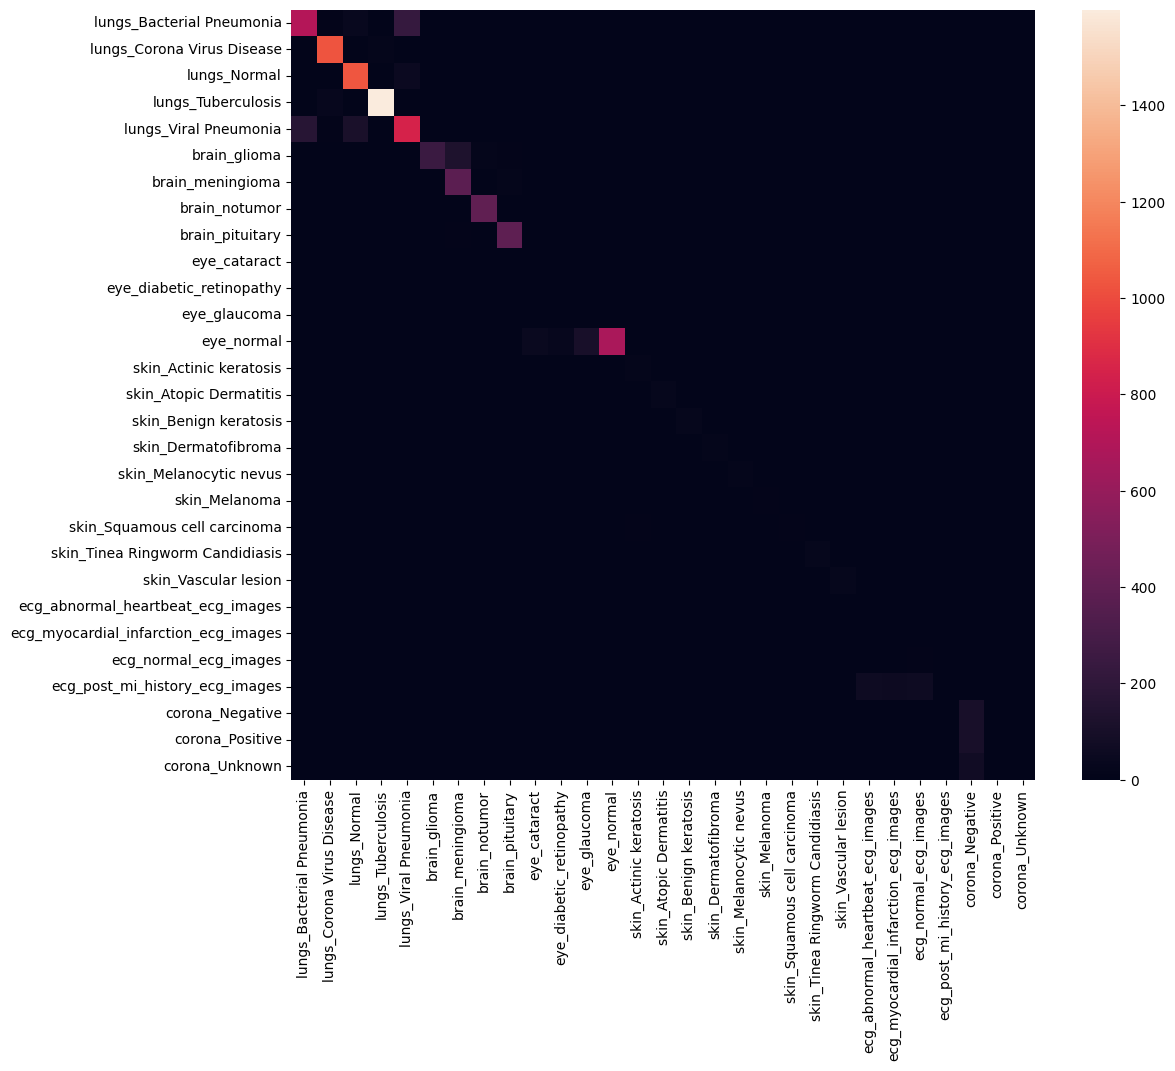

In [5]:
import os, sys, json, cv2, librosa, torch, timm, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. GLOBAL CONFIGURATION (Flexible Paths)
# ==========================================
class Config:
    seed = 42
    img_size = 256
    batch_size = 24
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # KAGGLE DATASET SLUGS (Matches your Sidebar)
    roots = {
        "eye": "/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset",
        "lungs": "/kaggle/input/datasets/omkarmanohardalvi/lungs-disease-dataset-4-types/Lung Disease Dataset",
        "skin": "/kaggle/input/datasets/riyaelizashaju/skin-disease-classification-image-dataset/Split_smol",
        "brain": "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset",
        "corona": "/kaggle/input/datasets/pranaynandan63/covid-19-cough-sounds/cleaned_data",
        "ecg": "/kaggle/input/datasets/evilspirit05/ecg-analysis/ecg_data_new_version/ecg data new version"
    }

    # IMMUTABLE LABEL MAPPING (0-28)
    DOMAIN_LABELS = {
        "lungs": ["Bacterial Pneumonia", "Corona Virus Disease", "Normal", "Tuberculosis", "Viral Pneumonia"],
        "brain": ["glioma", "meningioma", "notumor", "pituitary"],
        "eye": ["cataract", "diabetic_retinopathy", "glaucoma", "normal"],
        "skin": ["Actinic keratosis", "Atopic Dermatitis", "Benign keratosis", "Dermatofibroma", 
                 "Melanocytic nevus", "Melanoma", "Squamous cell carcinoma", 
                 "Tinea Ringworm Candidiasis", "Vascular lesion"],
        "ecg": ["abnormal_heartbeat_ecg_images", "myocardial_infarction_ecg_images", 
                "normal_ecg_images", "post_mi_history_ecg_images"],
        "corona": ["Negative", "Positive", "Unknown"]
    }

    domains = list(DOMAIN_LABELS.keys())
    offsets = {}; class_names = []; curr = 0
    for dom in domains:
        offsets[dom] = curr
        for cls in DOMAIN_LABELS[dom]: class_names.append(f"{dom}_{cls}")
        curr += len(DOMAIN_LABELS[dom])
    
    total_classes = len(class_names)
    out_dir = Path("/kaggle/working/medical_output")
    out_dir.mkdir(exist_ok=True)

# ==========================================
# 2. DATASET (Recursive Path Finding)
# ==========================================
class MedicalDataset(Dataset):
    def __init__(self, mode="train"):
        self.samples = []
        print(f"--- Loading {mode.upper()} Data ---")
        
        for dom in Config.domains:
            root = Path(Config.roots[dom])
            if not root.exists():
                print(f"⚠️ Path not found: {root}. Skipping {dom}.")
                continue
                
            f_to_idx = {name: i for i, name in enumerate(Config.DOMAIN_LABELS[dom])}
            dom_samples = []

            # Search RECURSIVELY for files
            # This bypasses the intermediate folder naming issues
            exts = ['*.jpg', '*.png', '*.jpeg', '*.wav']
            all_files = []
            for e in exts: all_files.extend(list(root.rglob(e)))
            
            # Sort files to ensure deterministic splits (Anti-Leakage)
            all_files = sorted(all_files)

            for f in all_files:
                class_name = f.parent.name
                if class_name in f_to_idx:
                    # LEAKAGE PROTECTION: Filter by folder path or manual split
                    path_str = str(f).lower()
                    
                    is_train_path = any(x in path_str for x in ["train", "training"])
                    is_test_path = any(x in path_str for x in ["test", "testing", "val", "validation"])

                    # Logic: If dataset has official splits, use them. Else, split by index.
                    if any(x in path_str for x in ["train", "test", "val", "testing", "training"]):
                        if mode == "train" and is_train_path: pass
                        elif mode == "test" and is_test_path: pass
                        else: continue # Skip if split doesn't match mode
                    else:
                        # Manual Split for datasets like Eye/ECG/Corona
                        idx_in_dom = all_files.index(f)
                        split_limit = int(len(all_files) * 0.8)
                        if mode == "train" and idx_in_dom >= split_limit: continue
                        if mode == "test" and idx_in_dom < split_limit: continue

                    self.samples.append({
                        "path": str(f), "dom_idx": Config.domains.index(dom),
                        "label": Config.offsets[dom] + f_to_idx[class_name],
                        "type": "audio" if f.suffix == ".wav" else "image"
                    })
                    dom_samples.append(f)

            print(f"  ✅ {dom.upper()}: {len(dom_samples)} samples added.")
        
        if mode == "train":
            np.random.seed(Config.seed); np.random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        s = self.samples[i]
        try:
            if s["type"] == "audio":
                y, _ = librosa.load(s["path"], sr=16000, duration=3.0)
                if len(y) < 48000: y = np.pad(y, (0, 48000 - len(y)))
                spec = librosa.feature.melspectrogram(y=y, sr=16000, n_mels=128)
                img = cv2.resize(librosa.power_to_db(spec, ref=np.max), (Config.img_size, Config.img_size))
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                img = np.stack([img]*3, axis=0)
            else:
                img = cv2.imread(s["path"])
                img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (Config.img_size, Config.img_size))
                img = img.transpose(2, 0, 1) / 255.0
            return torch.tensor(img).float(), s["dom_idx"], s["label"]
        except: return torch.zeros((3, Config.img_size, Config.img_size)), s["dom_idx"], 0

    def get_weights(self):
        labels = [s['label'] for s in self.samples]
        counts = np.bincount(labels, minlength=Config.total_classes)
        return torch.DoubleTensor([1. / (counts[l] + 1e-6) for l in labels])

# ==========================================
# 3. MoE + LoRA ADAPTERS
# ==========================================
class MedicalMoE(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0)
        for p in self.backbone.parameters(): p.requires_grad = False 
        
        self.target_layer = self.backbone.conv_head 
        dim = self.backbone.num_features
        self.router = nn.Sequential(nn.Linear(dim, 256), nn.ReLU(), nn.Linear(256, len(Config.domains)))
        
        self.heads = nn.ModuleDict({
            dom: nn.Sequential(nn.Linear(dim, 512), nn.LayerNorm(512), nn.ReLU(), 
                               nn.Linear(512, len(Config.DOMAIN_LABELS[dom])))
            for dom in Config.domains
        })
        self.lora_A = nn.ParameterDict({d: nn.Parameter(torch.randn(dim, 8)*0.01) for d in Config.domains})
        self.lora_B = nn.ParameterDict({d: nn.Parameter(torch.zeros(8, dim)) for d in Config.domains})

    def forward(self, x, force_dom=None):
        feats = self.backbone(x)
        dom_logits = self.router(feats)
        pred_dom = torch.argmax(dom_logits, dim=1) if force_dom is None else force_dom
        
        final_logits = torch.full((x.size(0), Config.total_classes), -10000.0, dtype=feats.dtype, device=x.device)
        for idx, dom_name in enumerate(Config.domains):
            mask = (pred_dom == idx)
            if mask.any():
                adapted = feats[mask] + (feats[mask] @ self.lora_A[dom_name] @ self.lora_B[dom_name]) * 2.0
                h_out = self.heads[dom_name](adapted)
                start = Config.offsets[dom_name]
                final_logits[mask, start : start + h_out.size(1)] = h_out
        return final_logits, dom_logits

# ==========================================
# 4. ENGINE (Train, Eval, HiResCAM, ONNX)
# ==========================================
class Engine:
    def __init__(self, model):
        self.model = model.to(Config.device)
        self.scaler = GradScaler('cuda')

    def train(self, loader):
        opt = optim.AdamW(filter(lambda p: p.requires_grad, self.model.parameters()), lr=2e-4)
        for epoch in range(5):
            pbar = tqdm(loader, desc=f"Epoch {epoch+1}")
            for x, d, y in pbar:
                x, d, y = x.to(Config.device), d.to(Config.device), y.to(Config.device)
                opt.zero_grad()
                with autocast('cuda'):
                    logits, d_logits = self.model(x, force_dom=d)
                    loss = F.cross_entropy(logits, y) + 0.5 * F.cross_entropy(d_logits, d)
                self.scaler.scale(loss).backward()
                self.scaler.step(opt); self.scaler.update()

    def evaluate(self, loader):
        self.model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for x, d, y in tqdm(loader, desc="Testing"):
                l, _ = self.model(x.to(Config.device))
                all_p.extend(torch.argmax(l, dim=1).cpu().numpy())
                all_y.extend(y.numpy())
        
        print("\n" + "="*50 + "\nSECURE MEDICAL EVALUATION\n" + "="*50)
        print(classification_report(all_y, all_p, target_names=Config.class_names, zero_division=0))
        
        cm = confusion_matrix(all_y, all_p)
        plt.figure(figsize=(12, 10)); sns.heatmap(cm, cmap='rocket', xticklabels=Config.class_names, yticklabels=Config.class_names)
        plt.savefig(Config.out_dir / "conf_matrix.png")

    def export_onnx(self):
        self.model.eval().cpu()
        dummy = torch.randn(1, 3, Config.img_size, Config.img_size)
        torch.onnx.export(self.model, (dummy, torch.tensor([0])), Config.out_dir / "medical_moe.onnx", opset_version=12)

# ==========================================
# 5. EXECUTION
# ==========================================
if __name__ == "__main__":
    train_ds = MedicalDataset(mode="train")
    if len(train_ds) == 0:
        print("❌ FATAL: Train dataset is empty. Check your Kaggle Input Paths.")
    else:
        test_ds = MedicalDataset(mode="test")
        train_loader = DataLoader(train_ds, batch_size=Config.batch_size, 
                                  sampler=WeightedRandomSampler(train_ds.get_weights(), len(train_ds)), 
                                  num_workers=2)
        test_loader = DataLoader(test_ds, batch_size=Config.batch_size, shuffle=False)
        
        model = MedicalMoE(); engine = Engine(model)
        engine.train(train_loader)
        engine.evaluate(test_loader)
        engine.export_onnx()
        torch.save(model.state_dict(), Config.out_dir / "medical_moe_final.pth")
        print(f"✅ Success. Results in {Config.out_dir}")